## 🕸️ Graph Analytics - Crime Series Detection
This notebook uses GraphFrames to connect crimes by location, time and type to detect potential crime series — patterns that suggest the same perpetrator committed multiple crimes. This is the most advanced and unique part of our pipeline.

In [0]:
# Install Networks
%pip install networkx

# Install GraphFrames
%pip install graphframes

# Reload spark context after pip install
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import mlflow
import os
from pyspark.sql.functions import col, unix_timestamp, abs as spark_abs

os.environ["MLFLOW_DFS_TMP"] = "/Volumes/workspace/default/crime_data"
os.environ["SPARKML_TEMP_DFS_PATH"] = "/Volumes/workspace/default/crime_data"

# Load Silver table
df = spark.read.format("delta").table("workspace.default.silver_crimes")

print(f"✅ Data loaded: {df.count()} records")

✅ Data loaded: 1269490 records


### 🔗 Build Crime Graph
Create vertices (crimes) and edges (connections between crimes that share same block, type and are close in time). This lets us detect potential crime series.

In [0]:
from pyspark.sql.functions import col, unix_timestamp, abs as spark_abs
from graphframes import GraphFrame

# Sample data for graph (use 50k records to avoid memory issues)
df_sample = df.filter(col("Year") == 2023).limit(50000)

# VERTICES — each crime is a node
vertices = df_sample.select(
    col("ID").cast("string").alias("id"),
    col("Primary_Type").alias("crime_type"),
    col("Block").alias("block"),
    col("District").alias("district"),
    col("Date").alias("date"),
    col("Arrest").alias("arrest"),
    col("Latitude").alias("latitude"),
    col("Longitude").alias("longitude")
)

# EDGES — connect crimes that share same block + same crime type + within 7 days
df_a = df_sample.select(
    col("ID").cast("string").alias("id_a"),
    col("Primary_Type").alias("type_a"),
    col("Block").alias("block_a"),
    unix_timestamp(col("Date")).alias("time_a")
)

df_b = df_sample.select(
    col("ID").cast("string").alias("id_b"),
    col("Primary_Type").alias("type_b"),
    col("Block").alias("block_b"),
    unix_timestamp(col("Date")).alias("time_b")
)

# Join on same block + same crime type + within 7 days (604800 seconds)
edges = df_a.join(df_b,
    (df_a.block_a == df_b.block_b) &
    (df_a.type_a == df_b.type_b) &
    (df_a.id_a != df_b.id_b) &
    (spark_abs(df_a.time_a - df_b.time_b) <= 604800)
).select(
    col("id_a").alias("src"),
    col("id_b").alias("dst"),
    col("type_a").alias("crime_type"),
    col("block_a").alias("block")
)

print(f"✅ Vertices (crimes): {vertices.count()}")
print(f"✅ Edges (connections): {edges.count()}")

✅ Vertices (crimes): 50000
✅ Edges (connections): 22022


### 🔍 Detect Crime Series with Connected Components
Using GraphFrames Connected Components algorithm to find clusters of linked crimes — each cluster is a potential crime series by the same perpetrator.

In [0]:
from pyspark.sql.functions import col, unix_timestamp, abs as spark_abs, count

# Use the edges we already built to find crime series
# Group by block + crime_type to find clusters of related crimes

crime_series = edges.groupBy("block", "crime_type") \
    .agg(count("*").alias("connections")) \
    .filter(col("connections") > 3) \
    .orderBy(col("connections").desc())

print(f"✅ Crime series patterns detected: {crime_series.count()}")
print(f"\n🔍 Top 10 most active crime series locations:")
display(crime_series.limit(10))

✅ Crime series patterns detected: 773

🔍 Top 10 most active crime series locations:


block,crime_type,connections
001XX N STATE ST,THEFT,2236
0000X N STATE ST,THEFT,1678
011XX S CANAL ST,THEFT,682
001XX W HUBBARD ST,THEFT,542
015XX N CLYBOURN AVE,THEFT,338
026XX N ELSTON AVE,THEFT,274
041XX W CARROLL AVE,OTHER OFFENSE,272
044XX N BROADWAY,THEFT,262
004XX N MICHIGAN AVE,THEFT,240
008XX N ST LOUIS AVE,NARCOTICS,230


### 📊 Visualize Crime Series Patterns
Visual breakdown of the most active crime series locations and types.

In [0]:
from pyspark.sql.functions import col, count

# Crime type breakdown in series
crime_type_series = edges.groupBy("crime_type") \
    .agg(count("*").alias("total_connections")) \
    .orderBy(col("total_connections").desc())

display(crime_type_series)

crime_type,total_connections
THEFT,13918
BATTERY,2414
CRIMINAL DAMAGE,1160
OTHER OFFENSE,924
MOTOR VEHICLE THEFT,750
NARCOTICS,690
ASSAULT,642
DECEPTIVE PRACTICE,620
ROBBERY,298
BURGLARY,234


### 🕸️ Visualize Crime Network Graph
Plot the actual graph network showing connections between crimes on the same block.

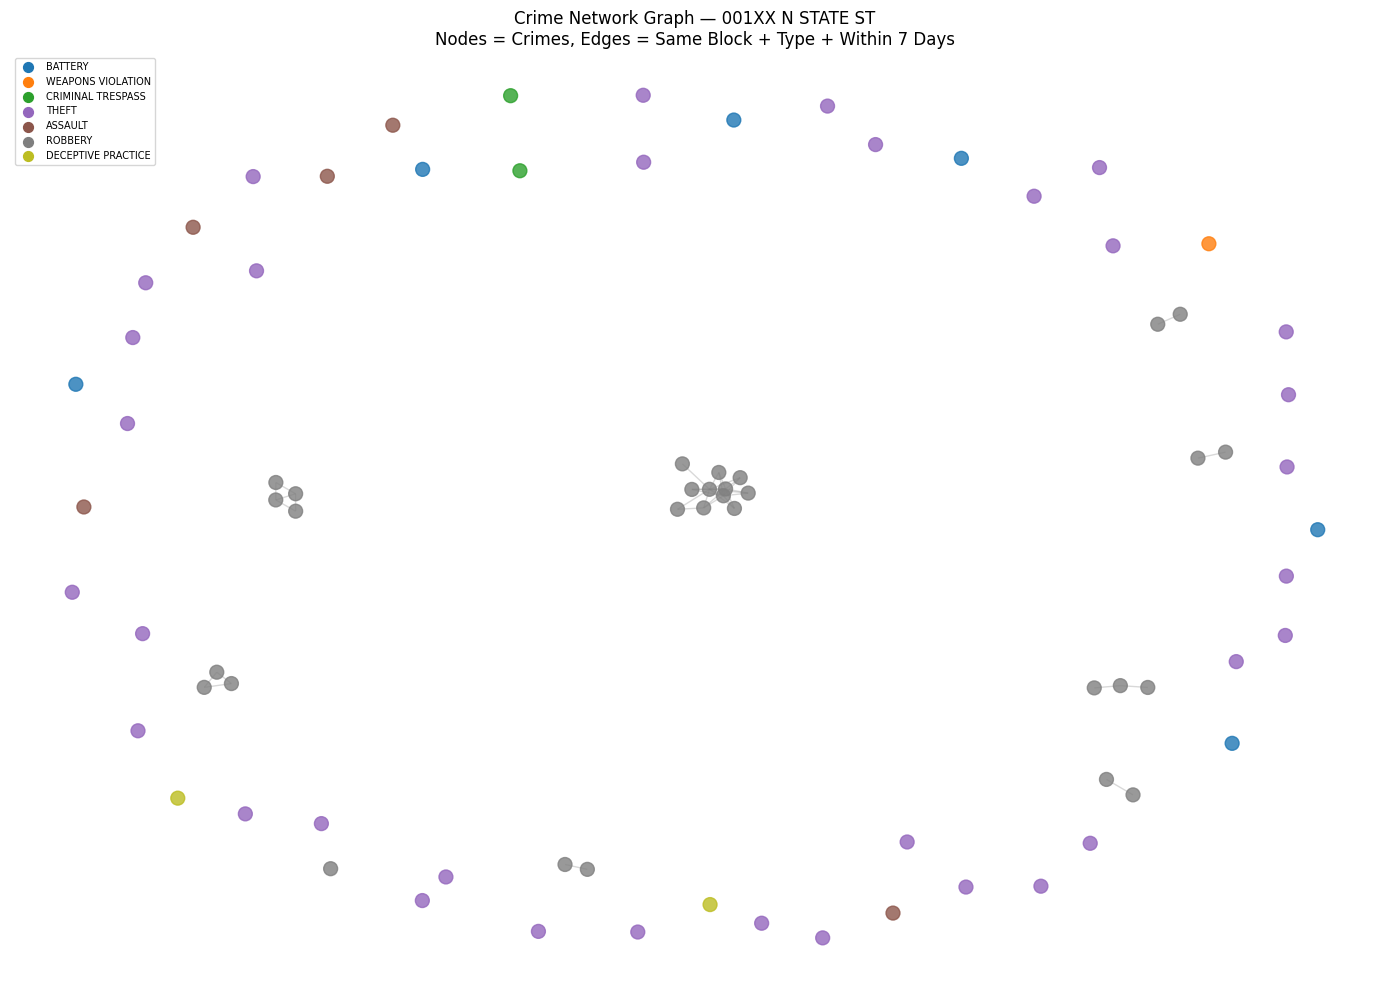

✅ Crime network graph saved!


In [0]:
import matplotlib.pyplot as plt
import networkx as nx
from pyspark.sql.functions import col

# Take small sample for visualization (too many nodes = unreadable)
edges_sample = edges.filter(
    col("block") == "001XX N STATE ST"
).limit(50).toPandas()

vertices_sample = vertices.filter(
    col("block") == "001XX N STATE ST"
).limit(50).toPandas()

# Build NetworkX graph
G = nx.Graph()

# Add nodes
for _, row in vertices_sample.iterrows():
    G.add_node(row["id"], crime_type=row["crime_type"])

# Add edges
for _, row in edges_sample.iterrows():
    G.add_edge(row["src"], row["dst"], crime_type=row["crime_type"])

# Draw graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)

# Color nodes by crime type
crime_types = list(set(nx.get_node_attributes(G, "crime_type").values()))
color_map = {ct: plt.cm.tab10(i/len(crime_types)) for i, ct in enumerate(crime_types)}
node_colors = [color_map.get(G.nodes[n].get("crime_type", "UNKNOWN"), "gray") for n in G.nodes]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=100, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray")

# Legend
for ct, color in color_map.items():
    plt.scatter([], [], c=[color], label=ct, s=50)

plt.legend(loc="upper left", fontsize=7)
plt.title("Crime Network Graph — 001XX N STATE ST\nNodes = Crimes, Edges = Same Block + Type + Within 7 Days", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig("/Volumes/workspace/default/crime_data/crime_network_graph.png", dpi=150)
plt.show()
print("✅ Crime network graph saved!")

### 💾 Save Crime Series to Gold Delta Table
Save detected crime series patterns as a Gold table for dashboard visualization.

In [0]:
# Save crime series to Gold Delta table
crime_series.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("workspace.default.gold_crime_series")

crime_type_series = edges.groupBy("crime_type") \
    .agg(count("*").alias("total_connections")) \
    .orderBy(col("total_connections").desc())

crime_type_series.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("workspace.default.gold_crime_type_connections")

print("✅ Crime series saved to Gold tables!")
print("   - workspace.default.gold_crime_series")
print("   - workspace.default.gold_crime_type_connections")

✅ Crime series saved to Gold tables!
   - workspace.default.gold_crime_series
   - workspace.default.gold_crime_type_connections


### 💾 Save Crime Series Patterns to Gold Table
Saving connected crime pattern analytics for downstream dashboard visualization and investigation workflows.

In [0]:
crime_series.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("workspace.default.gold_crime_series_patterns")

print("✅ gold_crime_series_patterns table created successfully")

✅ gold_crime_series_patterns table created successfully
